# Quadratic Positive Definite Optimization in 2D

We optimize a quadratic positive definite function

$
f(x_1,x_2) = x^T A x - b^T x + c,
$

where $A\succ 0$ is symmetric positive definite.  
We generate $A$ using $A = B^T B$ to guarantee positive definiteness.

We compare two optimization methods:

1. **Gradient Descent** (fixed learning rate = 0.01)
2. **Steepest Descent** (exact line search for quadratic)

We will:
- Plot contour lines of $f(x_1,x_2)$
- Plot the optimization paths on top of the contour plot


In [441]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [442]:
# ------------------------------
# 1) Construct a quadratic function:
#    f(x) = x^T A x - b^T x + c
#    where A = B^T B is SPD (symmetric positive definite)
# ------------------------------

np.random.seed(42)

# Generate a random B, then A = B^T B is SPD
B = np.random.randn(2, 2)
A = B.T @ B

# Generate b and c
b = np.array([2.0, -3.0])
c = 1.0

print("B =\n", B)
print("A = B^T B =\n", A)
print("b =", b)
print("c =", c)

# Define f(x) and grad f(x)
def f(x):
    # x is shape (2,)
    return x.T @ A @ x - b.T @ x + c

def grad_f(x):
    # Since A is symmetric: grad = (A + A^T)x - b = 2Ax - b
    return 2 * (A @ x) - b

# Closed-form minimizer (for checking):
# Set grad = 0 => 2Ax - b = 0 => x* = 0.5 A^{-1} b
x_star = 0.5 * np.linalg.solve(A, b)
print("\nClosed-form minimizer x* =", x_star)
print("f(x*) =", f(x_star))


B =
 [[ 0.4967 -0.1383]
 [ 0.6477  1.523 ]]
A = B^T B =
 [[0.6662 0.9178]
 [0.9178 2.3387]]
b = [ 2. -3.]
c = 1.0

Closed-form minimizer x* = [ 5.1904 -2.6782]
f(x*) = -8.207675740451318


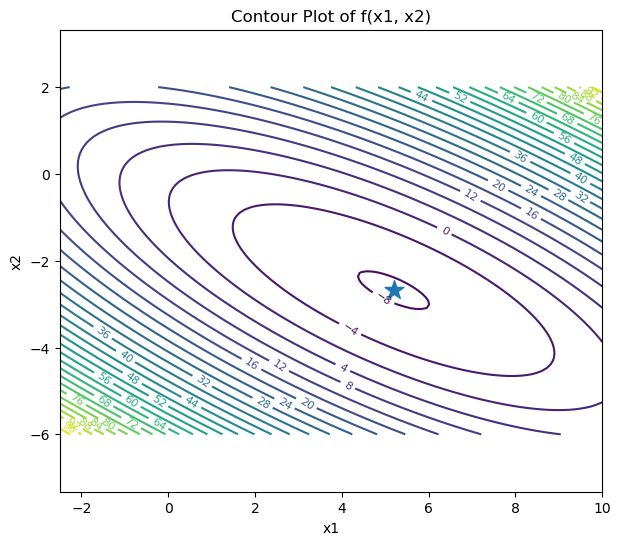

In [443]:
# ------------------------------
# 2) Plot contour of f(x1, x2)
# ------------------------------

# Create a grid for contour plot
x1_vals = np.linspace(-2.5, 10, 100)
x2_vals = np.linspace(-6, 2, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Evaluate f on grid
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i, j], X2[i, j]])
        Z[i, j] = f(x)

plt.figure(figsize=(7, 6))
contours = plt.contour(X1, X2, Z, levels=30)
plt.clabel(contours, inline=True, fontsize=8)

# Mark the true minimizer
plt.scatter([x_star[0]], [x_star[1]], marker='*', s=200)
plt.title("Contour Plot of f(x1, x2)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()


## Gradient Descent (Fixed Learning Rate = 0.01)

Update rule:

$
x_{k+1} = x_k - \alpha \nabla f(x_k)
$

where $\alpha = 0.01$ is fixed.


In [445]:
# ------------------------------
# 3) Gradient Descent with fixed learning rate
# ------------------------------

def gradient_descent_fixed_lr(x0, lr=0.01, max_iter=2000, tol=1e-8):
    x = x0.copy()
    path = [x.copy()]
    
    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - lr * g
        path.append(x.copy())
    
    return np.array(path), k+1

# Initial point
x0 = np.array([3.5, 3.0])

gd_path, gd_iters = gradient_descent_fixed_lr(x0, lr=0.01, max_iter=5000, tol=1e-10)
print("Gradient Descent finished in", gd_iters, "iterations")
print("Last point:", gd_path[-1])
print("f(last) =", f(gd_path[-1]))
print("||grad(last)|| =", np.linalg.norm(grad_f(gd_path[-1])))


Gradient Descent finished in 4536 iterations
Last point: [ 5.1904 -2.6782]
f(last) = -8.207675740451318
||grad(last)|| = 9.99028866452028e-11


## Steepest Descent (Exact Line Search for Quadratic)

Steepest descent uses direction $d_k = -\nabla f(x_k)$, but chooses step size by minimizing

$
\alpha_k = \arg\min_{\alpha>0} f(x_k + \alpha d_k)
$

For quadratic functions $f(x)=x^T A x - b^T x + c$.
With $g_k = \nabla f(x_k)$, the exact line search gives:

$
\alpha_k = \frac{g_k^T g_k}{g_k^T H g_k} = \frac{g_k^T g_k}{g_k^T (2A) g_k}
$


In [447]:
# ------------------------------
# 4) Steepest Descent with exact line search for quadratic
# ------------------------------

def steepest_descent_exact_linesearch(x0, max_iter=2000, tol=1e-8):
    x = x0.copy()
    path = [x.copy()]
    H = 2 * A  # Hessian for this quadratic
    
    for k in range(max_iter):
        g = grad_f(x)
        ng = np.linalg.norm(g)
        if ng < tol:
            break
        
        # exact line search step size for quadratic
        alpha = (g @ g) / (g @ (H @ g))
        
        # update
        x = x - alpha * g
        path.append(x.copy())
    
    return np.array(path), k+1

sd_path, sd_iters = steepest_descent_exact_linesearch(x0, max_iter=5000, tol=1e-10)
print("Steepest Descent finished in", sd_iters, "iterations")
print("Last point:", sd_path[-1])
print("f(last) =", f(sd_path[-1]))
print("||grad(last)|| =", np.linalg.norm(grad_f(sd_path[-1])))


Steepest Descent finished in 19 iterations
Last point: [ 5.1904 -2.6782]
f(last) = -8.207675740451318
||grad(last)|| = 7.855339753891898e-11


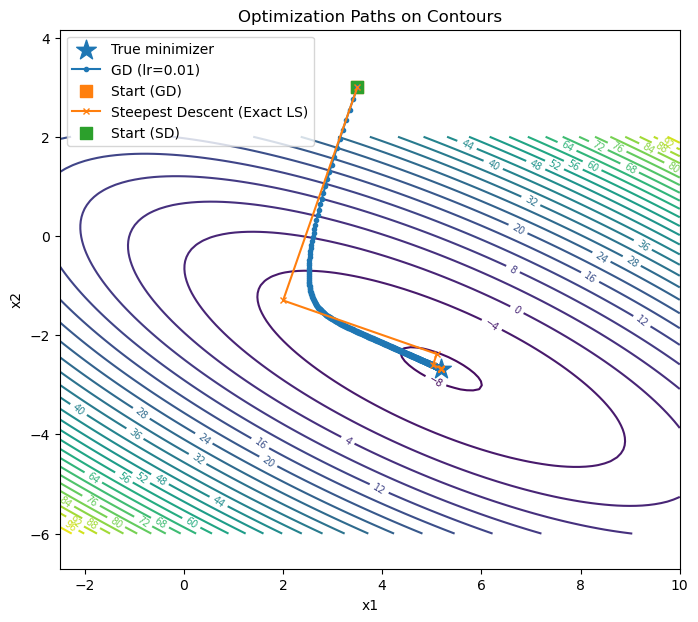

In [448]:
# ------------------------------
# 5) Plot optimization paths on the contour plot
# ------------------------------

plt.figure(figsize=(8, 7))
contours = plt.contour(X1, X2, Z, levels=35)
plt.clabel(contours, inline=True, fontsize=7)

# True minimizer
plt.scatter([x_star[0]], [x_star[1]], marker='*', s=220, label="True minimizer")

# GD path
plt.plot(gd_path[:, 0], gd_path[:, 1], marker='o', markersize=3, linewidth=1.5, label="GD (lr=0.01)")
plt.scatter([gd_path[0, 0]], [gd_path[0, 1]], s=80, marker='s', label="Start (GD)")

# Steepest descent path
plt.plot(sd_path[:, 0], sd_path[:, 1], marker='x', markersize=4, linewidth=1.5, label="Steepest Descent (Exact LS)")
plt.scatter([sd_path[0, 0]], [sd_path[0, 1]], s=80, marker='s', label="Start (SD)")

plt.title("Optimization Paths on Contours")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
#plt.xlim(4.5,6)
#plt.ylim(-3,-2)
plt.show()


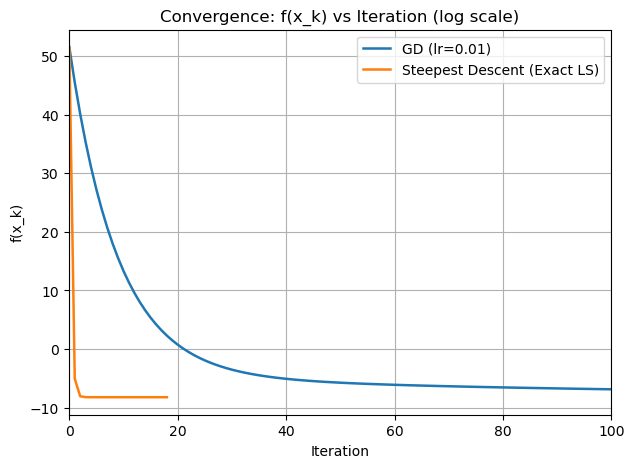

In [449]:
# ------------------------------
# 6) (Optional) Compare convergence by plotting f(x_k) vs iteration
# ------------------------------

gd_fvals = np.array([f(x) for x in gd_path])
sd_fvals = np.array([f(x) for x in sd_path])

plt.figure(figsize=(7, 5))
plt.plot(gd_fvals, linewidth=1.8, label="GD (lr=0.01)")
plt.plot(sd_fvals, linewidth=1.8, label="Steepest Descent (Exact LS)")
plt.title("Convergence: f(x_k) vs Iteration (log scale)")
plt.xlabel("Iteration")
plt.ylabel("f(x_k)")
plt.legend()
plt.grid(True)
plt.xlim(-0.1,100)
plt.show()


# Steepest Descent vs. Conjugate Gradient on an SPD Quadratic

We consider an **n-dimensional** strictly convex quadratic function:

$
f(x) = x^\top A x - b^\top x + c
$

where $A$ is **symmetric positive definite (SPD)**.  
We generate $A$ as $A = B^\top B + \mu I$ to guarantee SPD.

We solve for the minimizer using:
- **Steepest Descent (SD)** with exact line search
- **Conjugate Gradient (CG)** (classic method for SPD systems)

Then we plot how the **function value** decreases with iteration steps.


In [451]:
import numpy as np
import matplotlib.pyplot as plt

def quad_value(A, b, c, x):
    """
    Compute f(x) = x^T A x - b^T x + c
    """
    return float(x.T @ A @ x - b.T @ x + c)

def grad(A, b, x):
    """
    Gradient of f(x) = x^T A x - b^T x + c is:
    ∇f(x) = (A + A^T) x - b
    For symmetric A, ∇f(x) = 2 A x - b
    """
    return 2 * (A @ x) - b


In [452]:
# Reproducibility
np.random.seed(42)

# Problem dimension
n = 9

# Generate SPD matrix A = B^T B + mu I
B = np.random.randn(n, n)
mu = 1e-2
A = B.T @ B + mu * np.eye(n)

# Generate vector b and scalar c
b = np.random.randn(n)
c = 0.0

# Initial point
x0 = np.zeros(n)

# (Optional) True minimizer for reference:
# For f(x)=x^T A x - b^T x + c, set gradient 2Ax - b = 0 => Ax = b/2
x_star = np.linalg.solve(A, 0.5 * b)
f_star = quad_value(A, b, c, x_star)

print("n =", n)
print("x*=",x_star)
print("f(x*) =", f_star)
print("||x*|| =", np.linalg.norm(x_star))


n = 9
x*= [ 1.3073 -0.3104  1.1536 -0.7944  0.9278  0.065   0.9134 -2.0391  0.3209]
f(x*) = -0.5959003598648993
||x*|| = 3.118884816030514


## Steepest Descent (with exact line search)

At iteration k:
- Direction: $p_k = -\nabla f(x_k)$
- Exact line search for quadratic gives a closed-form step size.

For our quadratic with gradient $g_k = 2Ax_k - b$:
$
\alpha_k = \frac{g_k^\top g_k}{2 g_k^\top A g_k}
$


In [454]:
def steepest_descent(A, b, c, x0, max_iter=100, tol=1e-10):
    """
    Steepest Descent on f(x)=x^T A x - b^T x + c with exact line search.

    Returns:
        xs: final x
        f_hist: list of f(x_k)
        g_norm_hist: list of ||grad|| values
    """
    x = x0.copy()
    f_hist = []
    g_norm_hist = []

    for k in range(max_iter):
        g = grad(A, b, x)
        g_norm = np.linalg.norm(g)

        f_hist.append(quad_value(A, b, c, x))
        g_norm_hist.append(g_norm)

        # Stop if gradient is small enough
        if g_norm < tol:
            break

        # Exact line search step size for this quadratic
        # alpha = (g^T g) / (2 g^T A g)
        denom = 2.0 * (g.T @ (A @ g))
        if denom <= 0:
            # Should not happen for SPD A (numerical issues aside)
            raise RuntimeError("Non-positive denominator encountered in line search.")

        alpha = (g.T @ g) / denom

        # Update
        x = x - alpha * g

    return x, np.array(f_hist), np.array(g_norm_hist)

x_sd, f_sd, g_sd = steepest_descent(A, b, c, x0, max_iter=10000, tol=1e-10)
print("SD iterations:", len(f_sd))
print("SD final f:", f_sd[-1])
print("SD final ||grad||:", g_sd[-1])


SD iterations: 7744
SD final f: -0.595900359864903
SD final ||grad||: 9.99304810159759e-11


## Conjugate Gradient (CG) on SPD quadratic

For our quadratic, minimizing $f(x)$ is equivalent to solving:
$
2 A x = b \quad \Leftrightarrow \quad A x = \frac{b}{2}
$

CG is designed for SPD systems and typically converges much faster than steepest descent.
We still record $f(x_k)$ at each step for a fair comparison.


In [456]:
def conjugate_gradient(A, b, c, x0, max_iter=None, tol=1e-10):
    """
    Conjugate Gradient to solve A x = b/2 (equivalent to minimizing the quadratic).

    We implement classic CG for SPD matrices:
      r_k = rhs - A x_k
      p_0 = r_0
      alpha_k = (r_k^T r_k) / (p_k^T A p_k)
      r_{k+1} = r_k - alpha_k A p_k
      beta_{k+1} = (r_{k+1}^T r_{k+1}) / (r_k^T r_k)
      p_{k+1} = r_{k+1} + beta_{k+1} p_k

    Returns:
        x: final x
        f_hist: list of f(x_k)
        r_norm_hist: list of ||r_k|| values
    """
    n = A.shape[0]
    if max_iter is None:
        max_iter = n  # In exact arithmetic, CG solves in at most n steps.

    rhs = 0.5 * b  # A x = b/2
    x = x0.copy()

    r = rhs - A @ x
    p = r.copy()

    f_hist = []
    r_norm_hist = []

    rs_old = float(r.T @ r)

    for k in range(max_iter):
        f_hist.append(quad_value(A, b, c, x))
        r_norm = np.linalg.norm(r)
        r_norm_hist.append(r_norm)

        if r_norm < tol:
            break

        Ap = A @ p
        denom = float(p.T @ Ap)
        if denom <= 0:
            # Should not happen for SPD A
            raise RuntimeError("Non-positive denominator encountered in CG step.")

        alpha = rs_old / denom
        x = x + alpha * p
        r = r - alpha * Ap

        rs_new = float(r.T @ r)
        beta = rs_new / rs_old
        p = r + beta * p
        rs_old = rs_new

    return x, np.array(f_hist), np.array(r_norm_hist)

x_cg, f_cg, r_cg = conjugate_gradient(A, b, c, x0, max_iter=100, tol=1e-10)
print("CG iterations:", len(f_cg)-1)
print("CG final f:", f_cg[-1])
print("CG final ||residual||:", r_cg[-1])


CG iterations: 9
CG final f: -0.5959003598649089
CG final ||residual||: 5.7517801917599584e-12


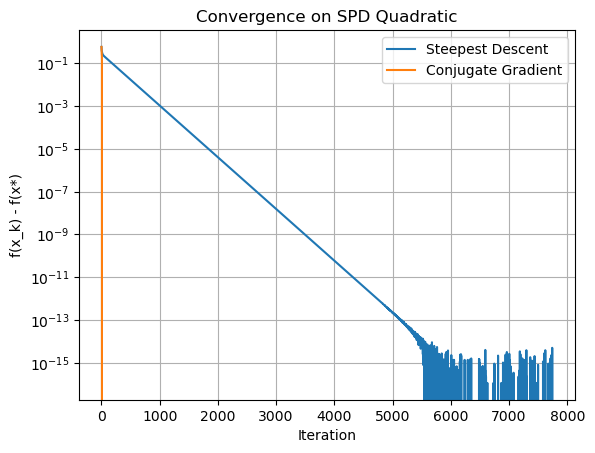

In [457]:
# Plot f(x_k) - f(x*) to show convergence more clearly (log scale)
sd_gap = f_sd - f_star
cg_gap = f_cg - f_star

plt.figure()
plt.plot(sd_gap, label="Steepest Descent")
plt.plot(cg_gap, label="Conjugate Gradient")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("f(x_k) - f(x*)")
plt.title("Convergence on SPD Quadratic")
plt.grid(True)
plt.legend()
plt.show()


In [458]:
# Compare distance to true minimizer x*
err_sd = np.linalg.norm(x_sd - x_star)
err_cg = np.linalg.norm(x_cg - x_star)

print("||x_sd - x*|| =", err_sd)
print("||x_cg - x*|| =", err_cg)


||x_sd - x*|| = 1.303804137400077e-09
||x_cg - x*|| = 2.8753001238925387e-13
